In [ ]:
print('='*50)
print('Importing libraries...')
print('='*50)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import ( 
    LinearRegression,
    ElasticNet,
     Ridge,
     Lasso
    )
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor
    )
from sklearn.model_selection import cross_val_score
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import GridSearchCV
import mlflow
import mlflow.sklearn


Importing libraries...


In [82]:
print('='*50)
print('Loading data...')
print('='*50)
df = pd.read_csv('../data/AmesHousing.csv')


Loading data...


In [83]:
print('='*50)
print('EDA for the  data...')
print('='*50)
df.head(5)

EDA for the  data...


,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,Utilities,Lot Config,Land Slope,Neighborhood,Condition 1,Condition 2,Bldg Type,House Style,Overall Qual,Overall Cond,Year Built,Year Remod/Add,Roof Style,Roof Matl,Exterior 1st,Exterior 2nd,Mas Vnr Type,Mas Vnr Area,Exter Qual,Exter Cond,Foundation,Bsmt Qual,Bsmt Cond,Bsmt Exposure,BsmtFin Type 1,BsmtFin SF 1,BsmtFin Type 2,BsmtFin SF 2,Bsmt Unf SF,Total Bsmt SF,...,Central Air,Electrical,1st Flr SF,2nd Flr SF,Low Qual Fin SF,Gr Liv Area,Bsmt Full Bath,Bsmt Half Bath,Full Bath,Half Bath,Bedroom AbvGr,Kitchen AbvGr,Kitchen Qual,TotRms AbvGrd,Functional,Fireplaces,Fireplace Qu,Garage Type,Garage Yr Blt,Garage Finish,Garage Cars,Garage Area,Garage Qual,Garage Cond,Paved Drive,Wood Deck SF,Open Porch SF,Enclosed Porch,3Ssn Porch,Screen Porch,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,1,526301100,20,RL,141.0,31770,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,NAmes,Norm,Norm,1Fam,1Story,6,5,1960,1960,Hip,CompShg,BrkFace,Plywood,Stone,112.0,TA,TA,CBlock,TA,Gd,Gd,BLQ,639.0,Unf,0.0,441.0,1080.0,...,Y,SBrkr,1656,0,0,1656,1.0,0.0,1,0,3,1,TA,7,Typ,2,Gd,Attchd,1960.0,Fin,2.0,528.0,TA,TA,P,210,62,0,0,0,0,NaN,NaN,NaN,0,5,2010,WD,Normal,215000
1,2,526350040,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,NAmes,Feedr,Norm,1Fam,1Story,5,6,1961,1961,Gable,CompShg,VinylSd,VinylSd,NaN,0.0,TA,TA,CBlock,TA,TA,No,Rec,468.0,LwQ,144.0,270.0,882.0,...,Y,SBrkr,896,0,0,896,0.0,0.0,1,0,2,1,TA,5,Typ,0,NaN,Attchd,1961.0,Unf,1.0,730.0,TA,TA,Y,140,0,0,0,120,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal,105000
2,3,526351010,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,NAmes,Norm,Norm,1Fam,1Story,6,6,1958,1958,Hip,CompShg,Wd Sdng,Wd Sdng,BrkFace,108.0,TA,TA,CBlock,TA,TA,No,ALQ,923.0,Unf,0.0,406.0,1329.0,...,Y,SBrkr,1329,0,0,1329,0.0,0.0,1,1,3,1,Gd,6,Typ,0,NaN,Attchd,1958.0,Unf,1.0,312.0,TA,TA,Y,393,36,0,0,0,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal,172000
3,4,526353030,20,RL,93.0,11160,Pave,NaN,Reg,Lvl,AllPub,Corner,Gtl,NAmes,Norm,Norm,1Fam,1Story,7,5,1968,1968,Hip,CompShg,BrkFace,BrkFace,NaN,0.0,Gd,TA,CBlock,TA,TA,No,ALQ,1065.0,Unf,0.0,1045.0,2110.0,...,Y,SBrkr,2110,0,0,2110,1.0,0.0,2,1,3,1,Ex,8,Typ,2,TA,Attchd,1968.0,Fin,2.0,522.0,TA,TA,Y,0,0,0,0,0,0,NaN,NaN,NaN,0,4,2010,WD,Normal,244000
4,5,527105010,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,Gilbert,Norm,Norm,1Fam,2Story,5,5,1997,1998,Gable,CompShg,VinylSd,VinylSd,NaN,0.0,TA,TA,PConc,Gd,TA,No,GLQ,791.0,Unf,0.0,137.0,928.0,...,Y,SBrkr,928,701,0,1629,0.0,0.0,2,1,3,1,TA,6,Typ,1,TA,Attchd,1997.0,Fin,2.0,482.0,TA,TA,Y,212,34,0,0,0,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal,189900


In [84]:
df = df.drop(["Order", "PID"], axis=1)

In [85]:
df.isnull().sum().sort_values(ascending=False).head(24)


Pool QC           2917
Misc Feature      2824
Alley             2732
Fence             2358
Mas Vnr Type      1775
Fireplace Qu      1422
Lot Frontage       490
Garage Yr Blt      159
Garage Qual        159
Garage Cond        159
Garage Finish      159
Garage Type        157
Bsmt Exposure       83
BsmtFin Type 2      81
Bsmt Qual           80
BsmtFin Type 1      80
Bsmt Cond           80
Mas Vnr Area        23
Bsmt Full Bath       2
Bsmt Half Bath       2
BsmtFin SF 2         1
Garage Area          1
Total Bsmt SF        1
BsmtFin SF 1         1
dtype: int64

In [86]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2930 entries, 0 to 2929
Data columns (total 80 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   MS SubClass      2930 non-null   int64  
 1   MS Zoning        2930 non-null   object 
 2   Lot Frontage     2440 non-null   float64
 3   Lot Area         2930 non-null   int64  
 4   Street           2930 non-null   object 
 5   Alley            198 non-null    object 
 6   Lot Shape        2930 non-null   object 
 7   Land Contour     2930 non-null   object 
 8   Utilities        2930 non-null   object 
 9   Lot Config       2930 non-null   object 
 10  Land Slope       2930 non-null   object 
 11  Neighborhood     2930 non-null   object 
 12  Condition 1      2930 non-null   object 
 13  Condition 2      2930 non-null   object 
 14  Bldg Type        2930 non-null   object 
 15  House Style      2930 non-null   object 
 16  Overall Qual     2930 non-null   int64  
 17  Overall Cond  

In [87]:
# Drop the "Alley" column due to a large number of missing values
df = df.drop("Alley", axis=1)

In [88]:
df["Lot Frontage"].fillna(df["Lot Frontage"].mean(), inplace=True)

C:\Users\PC\AppData\Local\Temp\ipykernel_14868\3916822336.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["Lot Frontage"].fillna(df["Lot Frontage"].mean(), inplace=True)


In [89]:
# features to be used for modeling
features = [
    "Overall Qual",
    "Gr Liv Area",
    "Garage Cars",
    "Garage Area",
    "Total Bsmt SF",
    "1st Flr SF",
    "Full Bath",
    "Year Built"
]

In [90]:
df[features].isnull().sum()

Overall Qual     0
Gr Liv Area      0
Garage Cars      1
Garage Area      1
Total Bsmt SF    1
1st Flr SF       0
Full Bath        0
Year Built       0
dtype: int64

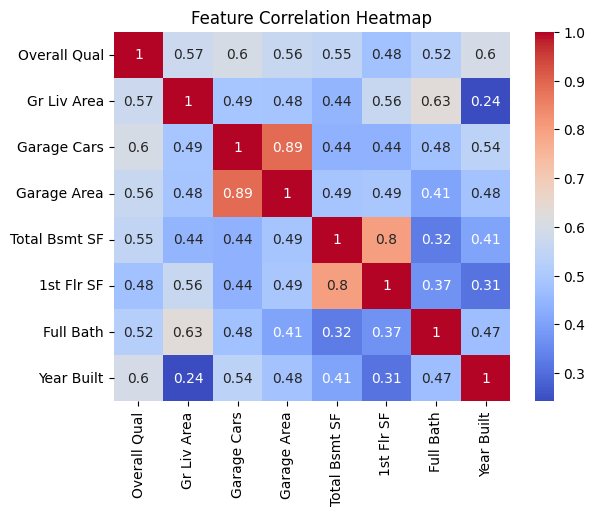

In [118]:
sns.heatmap(df[features].corr(), annot=True, cmap="coolwarm")
plt.title("Feature Correlation Heatmap")
plt.show()


In [91]:
# fill missing values in "Garage Area" with the mean value
df['Garage Cars'].fillna(df['Garage Cars'].mean(), inplace=True)

C:\Users\PC\AppData\Local\Temp\ipykernel_14868\3318684089.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Garage Cars'].fillna(df['Garage Cars'].mean(), inplace=True)


In [92]:
# fill missing values in "Garage Area" with the mean value
df['Garage Area'].fillna(df['Garage Area'].mean(), inplace=True)

C:\Users\PC\AppData\Local\Temp\ipykernel_14868\27385547.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Garage Area'].fillna(df['Garage Area'].mean(), inplace=True)


In [93]:
# fill missing values in "Total Bsmt SF" with the mean value
df['Total Bsmt SF'].fillna(df['Total Bsmt SF'].mean(), inplace=True)

C:\Users\PC\AppData\Local\Temp\ipykernel_14868\375734609.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Total Bsmt SF'].fillna(df['Total Bsmt SF'].mean(), inplace=True)


In [94]:
# check the data types and  missing values after filling
df[features].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2930 entries, 0 to 2929
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Overall Qual   2930 non-null   int64  
 1   Gr Liv Area    2930 non-null   int64  
 2   Garage Cars    2930 non-null   float64
 3   Garage Area    2930 non-null   float64
 4   Total Bsmt SF  2930 non-null   float64
 5   1st Flr SF     2930 non-null   int64  
 6   Full Bath      2930 non-null   int64  
 7   Year Built     2930 non-null   int64  
dtypes: float64(3), int64(5)
memory usage: 183.3 KB


In [95]:
# Check the count for exampole
df[features].count()

Overall Qual     2930
Gr Liv Area      2930
Garage Cars      2930
Garage Area      2930
Total Bsmt SF    2930
1st Flr SF       2930
Full Bath        2930
Year Built       2930
dtype: int64

In [96]:
# Prepare the data for modeling
X = df[features]
y = df['SalePrice']

In [97]:
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [98]:
# # Scale the features
# scler = StandardScaler()
# X_scaled = scler.fit_transform(X)

In [99]:
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

In [100]:

print("R2:", r2_score(y_test, y_pred))

R2: 0.8037202224306997


In [ ]:
# Check if 'SalePrice' is in the columns of X
"SalePrice" in X.columns

False

In [ ]:
# Check the model's performance on the training set
model.score(X_train, y_train)

0.7855851880413622

In [105]:
model = RandomForestRegressor(n_estimators=200, max_depth=10)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

from sklearn.metrics import r2_score
print("R2:", r2_score(y_test, y_pred))

R2: 0.8618169031451611


Text(0.5, 1.0, 'Actual vs Predicted')

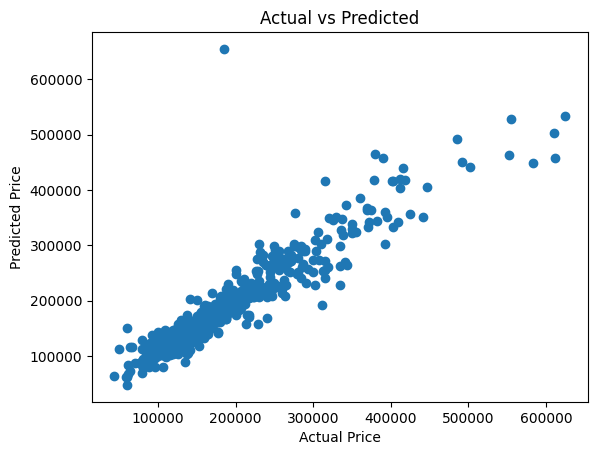

In [106]:
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted")

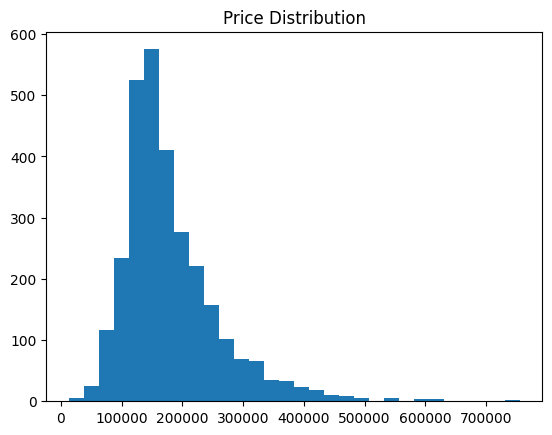

In [107]:
plt.hist(y, bins=30)
plt.title("Price Distribution")
plt.show()

Text(0.5, 1.0, 'Feature Importance')

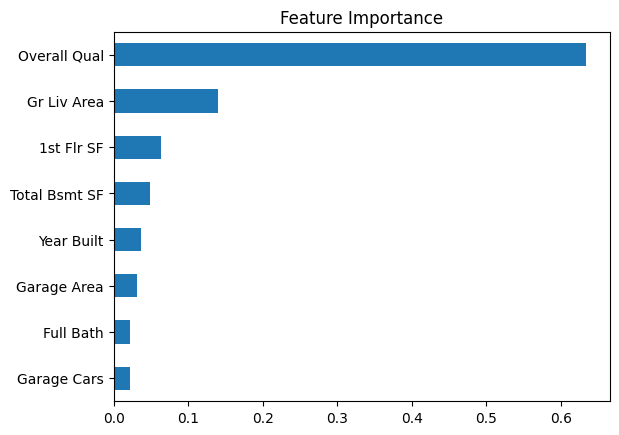

In [108]:
importances = model.feature_importances_
feature_names = X.columns

feat_imp = pd.Series(importances, index=feature_names)
feat_imp.sort_values().plot(kind='barh')

plt.title("Feature Importance")

In [127]:


def evaluate_model(model, X_train, X_test, y_train, y_test, name):

    with mlflow.start_run(run_name=name):

        # Log model name
        mlflow.set_tag("model", name)

        # Train
        model.fit(X_train, y_train)

        # Predictions
        y_train_pred = model.predict(X_train)
        y_test_pred = model.predict(X_test)

        # Metrics
        train_r2 = r2_score(y_train, y_train_pred)
        test_r2 = r2_score(y_test, y_test_pred)
        mse = mean_squared_error(y_test, y_test_pred)
        rmse = np.sqrt(mse)

        # Cross Validation
        cv_scores = cross_val_score(model, X_train, y_train, cv=5, scoring='r2')
        cv_mean = cv_scores.mean()
        cv_std = cv_scores.std()

        # Overfitting gap
        gap = abs(train_r2 - test_r2)

        # 🔥 Log metrics
        mlflow.log_metric("train_r2", train_r2)
        mlflow.log_metric("test_r2", test_r2)
        mlflow.log_metric("mse", mse)
        mlflow.log_metric("rmse", rmse)
        mlflow.log_metric("cv_mean", cv_mean)
        mlflow.log_metric("cv_std", cv_std)
        mlflow.log_metric("overfitting_gap", gap)

        # 🔥 Log params 
        if hasattr(model, "get_params"):
            mlflow.log_params(model.get_params())

        # 🔥 Log model
        mlflow.sklearn.log_model(model, name)

        # Print
        print(f"\n🔧 {name}")
        print(f"MSE: {mse:.2f}")
        print(f"RMSE: {rmse:.2f}")
        print(f"Train R²: {train_r2:.4f}")
        print(f"Test  R²: {test_r2:.4f}")
        print(f"CV    R²: {cv_mean:.4f} ± {cv_std:.4f}")

        if gap > 0.1:
            print("⚠️ Overfitting detected")
        else:
            print("✅ Model is stable")

        return {
            "train_r2": train_r2,
            "test_r2": test_r2,
            "cv_mean": cv_mean,
            "cv_std": cv_std,
            "gap": gap,
            "mse": mse,
            "rmse": rmse
        }

In [128]:

models = {
    "Linear": LinearRegression(),
    'ElasticNet': ElasticNet(),
    "Ridge": Ridge(),
    "Lasso": Lasso(),
    'CatBoostRegressor': CatBoostRegressor(verbose=0),
    'GradientBoostingRegressor': GradientBoostingRegressor(n_estimators=200),
    'RandomForest': RandomForestRegressor(n_estimators=200),
    'KNeighborsRegressor': KNeighborsRegressor(n_neighbors=5),
    'XGBoost': XGBRegressor(n_estimators=300)
}

results = {}

for name, model in models.items():
    results[name] = evaluate_model(model, X_train, X_test, y_train, y_test, name)

2026/04/06 18:04:31 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/04/06 18:04:31 INFO mlflow.store.db.utils: Updating database tables
2026/04/06 18:04:35 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/06 18:04:35 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/04/06 18:04:56 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.



🔧 Linear
MSE: 1573682524.53
RMSE: 39669.67
Train R²: 0.7856
Test  R²: 0.8037
CV    R²: 0.7782 ± 0.0439
✅ Model is stable


2026/04/06 18:04:56 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/04/06 18:04:59 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.



🔧 ElasticNet
MSE: 1640145235.78
RMSE: 40498.71
Train R²: 0.7755
Test  R²: 0.7954
CV    R²: 0.7679 ± 0.0511
✅ Model is stable


2026/04/06 18:04:59 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/04/06 18:05:02 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


...


🔧 RandomForest
MSE: 1101707149.92
RMSE: 33191.97
Train R²: 0.9805
Test  R²: 0.8626
CV    R²: 0.8586 ± 0.0283
⚠️ Overfitting detected


2026/04/06 18:05:33 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html



🔧 KNeighborsRegressor
MSE: 1602438845.01
RMSE: 40030.47
Train R²: 0.8250
Test  R²: 0.8001
CV    R²: 0.7277 ± 0.0357
✅ Model is stable


2026/04/06 18:05:38 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/06 18:05:38 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html



🔧 XGBoost
MSE: 1140525056.00
RMSE: 33771.66
Train R²: 0.9992
Test  R²: 0.8577
CV    R²: 0.8392 ± 0.0161
⚠️ Overfitting detected
